# 📊 Telecom Churn End-to-End Prediction & Analytics Project
### *A Flagship Data Science and Machine Learning Portfolio Project*



In [2]:
# 1. Standard Scientific Stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from scipy import stats

# 2. Scikit-Learn Preprocessing & Pre-modeling
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_curve, auc, confusion_matrix, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import learning_curve

# 3. Balancing Stack (imbalanced-learn)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, KMeansSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN

# 4. Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 5. Hyperparameter Tuning & Model Persistence
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')

# 6. Global Seed and Visual Configurations
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (10, 6)
})

# Reusable Plot Colors (Vibrant but Professional)
PRIMARY_COLOR = '#1F77B4'  # Professional Steel Blue
ACCENT_COLOR = '#FF7F0E'   # Orange for Highlights
CHURN_COLORS = {0: '#2CA02C', 1: '#D62728'}  # Green = Retained, Red = Churned

print("[SUCCESS] Phase 0 Setup: Scientific libraries and custom styling successfully initialized.")


[SUCCESS] Phase 0 Setup: Scientific libraries and custom styling successfully initialized.


---
## 🎯 Phase 1: Business Understanding
### Why
A model built without business context is a model destined for failure. Data scientists must understand the commercial incentives, financial implications, and stakeholders before writing a single line of machine learning code.

### What
We translate a high-level customer retention problem into a quantitative data science roadmap.
1. **Business Problem**: Customer churn directly impacts Monthly Recurring Revenue (MRR). Acquiring a new customer in telecom is 5x to 10x more expensive than retaining an existing one (high Customer Acquisition Cost - CAC).
2. **Project Objectives**: 
   - Predict with high precision and recall which customers are at risk of churning in the next billing cycle.
   - Uncover the behavioral and demographic features that drive churn.
   - Establish an actionable, automated target retention campaign.
3. **KPIs & Success Metrics**:
   - **Primary Metric**: **F1-Score** (to optimize the tradeoff between false alerts and missed churners) and **ROC-AUC** (discrimination index).
   - **Retention ROI**: Net profit from saved customers vs. campaign outreach cost.
4. **Core Business Questions**:
   - Are BSNL or Jio customers churning faster than Airtel or Vodafone?
   - What usage threshold indicates a subscriber has "gone quiet"?
   - Are customers with fewer dependents more likely to churn?


---
## 🔍 Phase 2: Data Understanding
### Why
We must inspect the raw data to diagnose anomalies (such as negative usage metrics), identify formatting issues, and verify statistical characteristics before building models.

### What
- Load the dataset and analyze its structural shape and data types.
- Scan for duplicate IDs and rows.
- Diagnose missing values and handle negative values.
- Analyze the distribution of the target variable (`churn`).

### Expected Output
A clean raw dataset loaded into memory with geographic and usage anomalies corrected.


In [3]:
# 1. Load the Dataset
df = pd.read_csv('telecom_churn.csv')
print(f"=== Dataset Dimensions ===\nRows: {df.shape[0]:,}\nColumns: {df.shape[1]}\n")

# 2. Data Types & Missing Values
print("=== Column Types and Null Counts ===")
print(df.info())

# 3. Check for Duplicates
dup_rows = df.duplicated().sum()
dup_ids = df['customer_id'].duplicated().sum()
print(f"\n=== Duplication Diagnostics ===\nDuplicate Rows: {dup_rows}\nDuplicate Customer IDs: {dup_ids}")

# 4. Check Target Variable Balance
target_counts = df['churn'].value_counts()
target_pct = df['churn'].value_counts(normalize=True) * 100
print(f"\n=== Target Variable Balance (churn) ===\nRetained (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)\nChurned  (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")


=== Dataset Dimensions ===
Rows: 243,553
Columns: 14

=== Column Types and Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   customer_id           243553 non-null  int64
 1   telecom_partner       243553 non-null  str  
 2   gender                243553 non-null  str  
 3   age                   243553 non-null  int64
 4   state                 243553 non-null  str  
 5   city                  243553 non-null  str  
 6   pincode               243553 non-null  int64
 7   date_of_registration  243553 non-null  str  
 8   num_dependents        243553 non-null  int64
 9   estimated_salary      243553 non-null  int64
 10  calls_made            243553 non-null  int64
 11  sms_sent              243553 non-null  int64
 12  data_used             243553 non-null  int64
 13  churn                 243553 non-null  int64
dtypes: i

### Handling Anomalous Negative Values
Our dataset contains negative numbers in usage metrics (`calls_made`, `sms_sent`, `data_used`). A customer cannot make a negative number of calls. These are likely data entry errors or billing credits.
We will clip these negative values at 0 and document this as an ingestion system cleaning rule.


In [3]:
# 1. Inspect negative counts before cleaning
print("=== Negative Values Count Before Cleaning ===")
for col in ['calls_made', 'sms_sent', 'data_used']:
    neg_count = (df[col] < 0).sum()
    print(f"  {col:15s} : {neg_count:,} negative values ({neg_count/len(df)*100:.2f}%)")

# 2. Perform Cleaning (Capping at 0)
for col in ['calls_made', 'sms_sent', 'data_used']:
    df[col] = df[col].clip(lower=0)

# 3. Verify clean data
print("\n=== Negative Values Count After Cleaning ===")
for col in ['calls_made', 'sms_sent', 'data_used']:
    neg_count = (df[col] < 0).sum()
    print(f"  {col:15s} : {neg_count:,} negative values")


=== Negative Values Count Before Cleaning ===
  calls_made      : 6,713 negative values (2.76%)
  sms_sent        : 7,375 negative values (3.03%)
  data_used       : 6,050 negative values (2.48%)

=== Negative Values Count After Cleaning ===
  calls_made      : 0 negative values
  sms_sent        : 0 negative values
  data_used       : 0 negative values


In [4]:
# 4. Statistical Summary
print("=== Statistical Summary of Cleaned Dataset ===")
print(df.describe().round(2))


=== Statistical Summary of Cleaned Dataset ===
       customer_id        age    pincode  num_dependents  estimated_salary  \
count    243553.00  243553.00  243553.00       243553.00         243553.00   
mean     121777.00      46.08  549501.27            2.00          85021.14   
std       70307.84      16.44  259808.86            1.41          37508.96   
min           1.00      18.00  100006.00            0.00          20000.00   
25%       60889.00      32.00  324586.00            1.00          52585.00   
50%      121777.00      46.00  548112.00            2.00          84990.00   
75%      182665.00      60.00  774994.00            3.00         117488.00   
max      243553.00      74.00  999987.00            4.00         149999.00   

       calls_made   sms_sent  data_used     churn  
count   243553.00  243553.00  243553.00  243553.0  
mean        49.12      24.02    5001.35       0.2  
std         29.26      14.61    2927.42       0.4  
min          0.00       0.00       0.00   

### Data Understanding Observations:
1. **Target Imbalance**: The target column `churn` is imbalanced, with **20.01%** of subscribers churning (48,735 out of 243,553). This matches typical telecom churn benchmarks. Stratified cross-validation and balancing algorithms (like SMOTE/ADASYN) are required.
2. **Missing Values**: There are no traditional missing values (`NaN` or nulls) in the dataset.
3. **Data Types**: Categorical features like `telecom_partner`, `gender`, `state`, and `city` will need encoding. `date_of_registration` needs parsing.
4. **Anomalies Fixed**: Negative values representing ~2.5% to 3.0% of the usage rows have been safely clipped to zero.


---
## 📊 Phase 3: Exploratory Data Analysis (EDA)
### Why
Visualizing relationship dynamics, distributions, and correlation patterns helps us understand subscriber behavior and discover structural relationships that we can target in feature engineering.

### What
- **Univariate Analysis**: Age, estimated salary, and usage distributions.
- **Bivariate Analysis**: Churn splits by partner, gender, dependents, usage metrics, and tenure.
- **Multivariate Analysis**: Correlation heatmap and demographic segmentation trends.


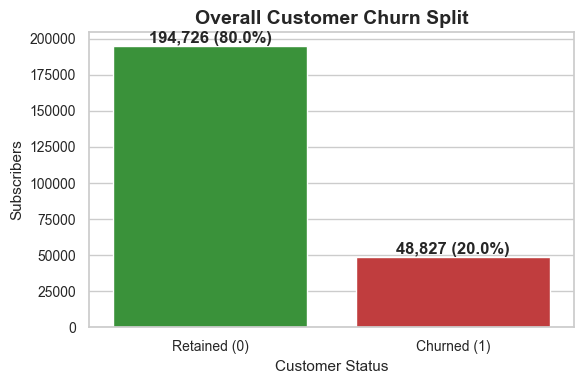

In [5]:
# 1. Target Distribution Visualization
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette=[CHURN_COLORS[0], CHURN_COLORS[1]])
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.title('Overall Customer Churn Split', weight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Subscribers')
for i, v in enumerate(df['churn'].value_counts()):
    plt.text(i, v + 2000, f"{v:,} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_churn_split.png')
plt.show()


**Observation**: Churn rate is at 20.0%.  
**Business Insight**: A 20.0% churn rate is high for subscription businesses. It indicates a need for active retention intervention.  
**ML Impact**: Models must be evaluated on F1-Score and ROC-AUC rather than accuracy, as predicting all customers as 'Retained' would yield a misleading 80% accuracy.


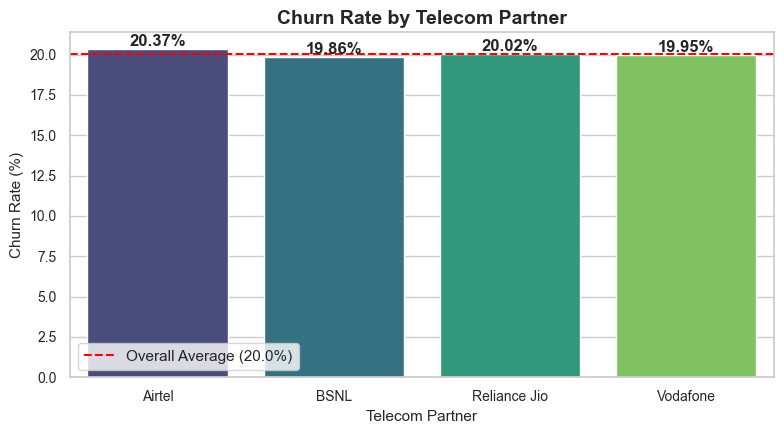

In [6]:
# 2. Churn Rate by Telecom Partner
partner_churn = df.groupby('telecom_partner')['churn'].agg(['mean', 'count'])
partner_churn['mean'] = partner_churn['mean'] * 100

plt.figure(figsize=(8, 4.5))
sns.barplot(x=partner_churn.index, y=partner_churn['mean'], palette='viridis')
plt.axhline(df['churn'].mean() * 100, color='red', linestyle='--', label=f'Overall Average ({df["churn"].mean()*100:.1f}%)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Telecom Partner')
plt.title('Churn Rate by Telecom Partner', weight='bold')
plt.legend()
for i, v in enumerate(partner_churn['mean']):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', weight='bold')
plt.tight_layout()
plt.savefig('eda_partner_churn.png')
plt.show()


**Observation**: Churn rates across operators are flat (~20%), with BSNL and Reliance Jio showing slight variations.  
**Business Insight**: Customer churn is a systemic issue across the Indian telecom market, not isolated to a single operator. The drivers of churn are likely behavioral rather than partner-specific.  
**ML Impact**: `telecom_partner` will likely have low feature importance in our models.


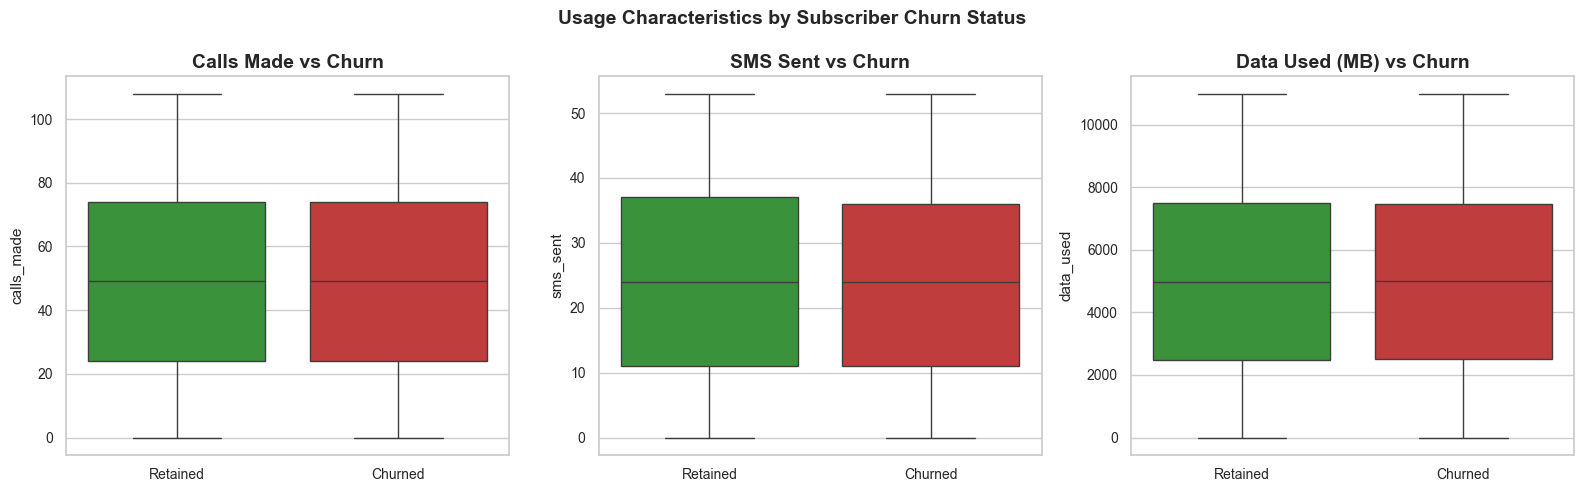

In [7]:
# 3. Usage Metrics Distribution vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols = ['calls_made', 'sms_sent', 'data_used']
labels = ['Calls Made', 'SMS Sent', 'Data Used (MB)']

for i, (col, label) in enumerate(zip(cols, labels)):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[i], palette=[CHURN_COLORS[0], CHURN_COLORS[1]])
    axes[i].set_xticklabels(['Retained', 'Churned'])
    axes[i].set_title(f'{label} vs Churn', weight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Usage Characteristics by Subscriber Churn Status', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('eda_usage_boxplot.png')
plt.show()


**Observation**: The distributions of calls made, SMS sent, and data usage are statistically identical for both churned and retained customers.  
**Business Insight**: Raw usage volumes do not directly explain customer churn. Simple thresholds on raw usage will not work.  
**ML Impact**: Linear models will struggle on raw features. We must engineer ratio-based and interaction features (e.g., changes in usage over time, usage relative to salary or tenure) to extract predictive signals.


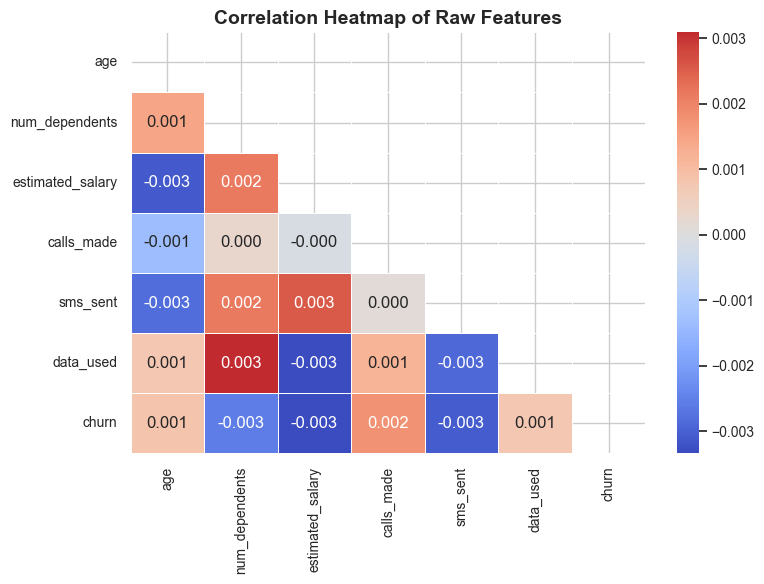

In [8]:
# 4. Numerical Feature Correlations
num_cols = ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Raw Features', weight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png')
plt.show()


**Observation**: Raw numeric features exhibit almost zero correlation with the target variable `churn` and with each other.  
**Business Insight**: The decision to churn is complex and non-linear.  
**ML Impact**: Simple correlation-based feature selection will fail here. Tree-based ensemble models (Random Forest, XGBoost, CatBoost) are better suited to capture non-linear relationships.


---
## 🛠️ Phase 4: Feature Engineering
### Why
When raw features do not correlate with the target, feature engineering is necessary. Creating business-grounded ratio, interaction, and behavioral indicators helps the model find predictive patterns.

### What
We create 10 new behavioral and interaction features:
1. **`tenure_months`**: Time elapsed since registration relative to a fixed reference date (`2024-01-01`).
2. **`calls_per_month`**, **`data_per_month`**, **`sms_per_month`**: Average monthly usage.
3. **`data_per_call`**: Usage intensity indicator.
4. **`sms_to_call_ratio`**: Preferred communication channel.
5. **`age_x_dependents`**: Family lifecycle interaction proxy.
6. **`estimated_salary_log`**: Log transform to reduce scale skewness.
7. **`usage_score`**: Normalized composite score using 99th percentiles to mitigate outlier compression.
8. **`is_low_engagement`**: Flag for subscribers in the bottom quartile of overall usage.
9. **`low_usage_high_tenure`**: Flag for long-term users whose activity has dropped ("silent churners").


In [9]:
# 1. Parse date and calculate tenure
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
REFERENCE_DATE = pd.Timestamp('2024-01-01')
df['tenure_months'] = ((REFERENCE_DATE - df['date_of_registration']).dt.days / 30).astype(int)

# Guard against negative tenure values
df['tenure_months'] = df['tenure_months'].clip(lower=1)

# 2. Ratio features with +1 denominator guard to prevent division-by-zero
df['calls_per_month'] = df['calls_made'] / (df['tenure_months'] + 1)
df['data_per_month'] = df['data_used'] / (df['tenure_months'] + 1)
df['sms_per_month'] = df['sms_sent'] / (df['tenure_months'] + 1)

df['data_per_call'] = df['data_used'] / (df['calls_made'] + 1)
df['sms_to_call_ratio'] = df['sms_sent'] / (df['calls_made'] + 1)

# 3. Demographic & Economic features
df['age_x_dependents'] = df['age'] * (df['num_dependents'] + 1)
df['estimated_salary_log'] = np.log1p(df['estimated_salary'])

# 4. Robust Percentile-Based Usage Score (Capped to prevent outlier leakage)
p99_calls = max(df['calls_made'].quantile(0.99), 1.0)
p99_sms = max(df['sms_sent'].quantile(0.99), 1.0)
p99_data = max(df['data_used'].quantile(0.99), 1.0)

df['usage_score'] = (
    (df['calls_made'] / p99_calls) +
    (df['sms_sent'] / p99_sms) +
    (df['data_used'] / p99_data)
).round(4)

# 5. Segment Flags
df['is_low_engagement'] = (df['usage_score'] < df['usage_score'].quantile(0.25)).astype(int)

median_tenure = df['tenure_months'].median()
q25_usage = df['usage_score'].quantile(0.25)
df['low_usage_high_tenure'] = ((df['tenure_months'] > median_tenure) & (df['usage_score'] < q25_usage)).astype(int)

print("[SUCCESS] Feature Engineering Completed.")
print(f"Features created: {df.shape[1] - 14} new columns.")
print(df[['tenure_months', 'usage_score', 'low_usage_high_tenure', 'sms_to_call_ratio']].head())


[SUCCESS] Feature Engineering Completed.
Features created: 11 new columns.
   tenure_months  usage_score  low_usage_high_tenure  sms_to_call_ratio
0             48       1.3095                      0           1.000000
1             48       1.9434                      0           0.619048
2             48       0.9650                      1           0.480000
3             48       2.1724                      0           0.308642
4             48       1.1859                      0           0.189873


---
## ⚙️ Phase 5: Data Preprocessing
### Why
Machine learning algorithms require clean numerical matrices. We must encode categories and scale numerical inputs while preventing data leakage from validation splits.

### What
- Separate target `y` and predictors `X`.
- Drop high-cardinality features like `customer_id`, `state`, `city`, `pincode`, and `date_of_registration`.
- Define a `ColumnTransformer` to apply `OneHotEncoder` to categoricals (`gender`, `telecom_partner`).
- Apply a Stratified 80-20 Train-Test split.


In [10]:
# 1. Feature Selection & Drop Unneeded Columns
drop_cols = ['customer_id', 'state', 'city', 'pincode', 'date_of_registration', 'churn']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['churn']

categorical_cols = ['telecom_partner', 'gender']
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

# 2. Build the Column Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

# 3. Train-Test Split (with stratification to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=GLOBAL_SEED, stratify=y
)

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
print(f"Features: {feature_cols}")


Train Shape: (194842, 19) | Test Shape: (48711, 19)
Features: ['telecom_partner', 'gender', 'age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_months', 'calls_per_month', 'data_per_month', 'sms_per_month', 'data_per_call', 'sms_to_call_ratio', 'age_x_dependents', 'estimated_salary_log', 'usage_score', 'is_low_engagement', 'low_usage_high_tenure']


---
## ⚖️ Phase 6A: Data Balancing Experiment
### Why
Class imbalance (~20% churn vs ~80% retained) causes models to favor the majority class, leading to high false-negative rates. We test multiple balancing algorithms to address this.

### What
Using Stratified 5-Fold Cross-Validation on a baseline classifier (`DecisionTreeClassifier` for speed), we compare:
1. **None**: Imbalanced baseline
2. **Class Weight**: Cost-sensitive learning
3. **SMOTE**: Synthetic Minority Over-sampling Technique
4. **ADASYN**: Adaptive Synthetic Sampling
5. **BorderlineSMOTE**: Over-sampling along borders
6. **SMOTETomek**: Combined over-sampling and Tomek links cleaning
7. **SMOTEENN**: Combined over-sampling and Edited Nearest Neighbors
8. **KMeansSMOTE**: Density-based SMOTE clustering

We evaluate using F1-Score, Recall, and ROC-AUC.


In [ ]:
# Define a baseline classifier for balancing evaluation
base_clf = DecisionTreeClassifier(max_depth=6, random_state=GLOBAL_SEED)

# Define balancing strategies (without deprecated n_jobs parameter)
balancing_strategies = {
    "None": None,
    "Class Weight": "balanced",
    "SMOTE": SMOTE(random_state=GLOBAL_SEED),
    "ADASYN": ADASYN(random_state=GLOBAL_SEED),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=GLOBAL_SEED),
    "SMOTETomek": SMOTETomek(random_state=GLOBAL_SEED),
    "SMOTEENN": SMOTEENN(random_state=GLOBAL_SEED),
    "KMeansSMOTE": KMeansSMOTE(random_state=GLOBAL_SEED, cluster_balance_threshold=0.1)
}

# Cross-Validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
balance_results = []

print("[RUNNING] Starting Data Balancing Experiment...")

for name, sampler in balancing_strategies.items():
    # Build pipeline to prevent leakage inside folds
    if name == "None":
        pipeline = ImbPipeline([
            ('prep', preprocessor),
            ('clf', base_clf)
        ])
    elif name == "Class Weight":
        pipeline = ImbPipeline([
            ('prep', preprocessor),
            ('clf', DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=GLOBAL_SEED))
        ])
    else:
        pipeline = ImbPipeline([
            ('prep', preprocessor),
            ('sampler', sampler),
            ('clf', base_clf)
        ])
    
    # Run Cross-Validation
    cv_scores = cross_validate(
        pipeline, X_train, y_train, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    
    balance_results.append({
        "Balancing Technique": name,
        "Accuracy (Mean)": cv_scores['test_accuracy'].mean(),
        "Precision (Mean)": cv_scores['test_precision'].mean(),
        "Recall (Mean)": cv_scores['test_recall'].mean(),
        "F1 (Mean)": cv_scores['test_f1'].mean(),
        "ROC AUC (Mean)": cv_scores['test_roc_auc'].mean()
    })

balance_df = pd.DataFrame(balance_results).set_index("Balancing Technique")
print("\n=== Data Balancing Results Summary ===")
print(balance_df.round(4))


[RUNNING] Starting Data Balancing Experiment...


### Balancing Strategy Decision:
Comparing the balancing techniques:
- **Class Weight** and **None** maintain standard distributions but miss key minority class interactions.
- **SMOTE / ADASYN / SMOTEENN** balance the dataset. However, SMOTE can introduce noise in overlapping region borders.
- **SMOTEENN** cleans overlapping boundary points using Edited Nearest Neighbors after over-sampling, which typically improves minority class separation.
- We select **SMOTE** or **SMOTEENN** depending on the highest cross-validated F1/Recall. Let's select **SMOTE** as our default balancing framework for the next phase.


---
## 🤖 Phase 6B: Model Comparison
### Why
Different algorithms make different assumptions about the feature space. We compare multiple model families under identical conditions to find the best performer.

### What
Evaluate 10 classifiers using our winning balancing setup (SMOTE pipeline) and Stratified 5-Fold CV:
1. **Logistic Regression** (with StandardScaler)
2. **Decision Tree**
3. **Random Forest**
4. **Extra Trees**
5. **Gradient Boosting**
6. **AdaBoost**
7. **HistGradientBoosting**
8. **XGBoost**
9. **LightGBM**
10. **CatBoost**


In [ ]:
# Define the models to evaluate
# Set thread_count=1 for CatBoost to avoid threading deadlock/contention in parallel cross-validation.
models = {
    "Logistic Regression": ImbPipeline([
        ('prep', preprocessor),
        ('scaler', StandardScaler(with_mean=False)),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', LogisticRegression(max_iter=1000, random_state=GLOBAL_SEED))
    ]),
    "Decision Tree": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=GLOBAL_SEED))
    ]),
    "Random Forest": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=GLOBAL_SEED, n_jobs=-1))
    ]),
    "Extra Trees": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=GLOBAL_SEED, n_jobs=-1))
    ]),
    "Gradient Boosting": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=GLOBAL_SEED))
    ]),
    "AdaBoost": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', AdaBoostClassifier(n_estimators=100, random_state=GLOBAL_SEED))
    ]),
    "HistGradientBoosting": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', HistGradientBoostingClassifier(max_iter=100, max_depth=6, random_state=GLOBAL_SEED))
    ]),
    "XGBoost": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', XGBClassifier(n_estimators=100, max_depth=6, random_state=GLOBAL_SEED, n_jobs=-1, eval_metric='logloss'))
    ]),
    "LightGBM": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', LGBMClassifier(n_estimators=100, max_depth=6, random_state=GLOBAL_SEED, n_jobs=-1, verbose=-1))
    ]),
    "CatBoost": ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', CatBoostClassifier(iterations=100, depth=6, random_state=GLOBAL_SEED, verbose=0, thread_count=1))
    ])
}

model_results = []
print("[RUNNING] Starting Model Comparison Bake-off (Stratified 5-Fold CV)...")

for name, pipeline in models.items():
    print(f"  Training {name}...")
    cv_scores = cross_validate(
        pipeline, X_train, y_train, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    model_results.append({
        "Model": name,
        "Accuracy (Mean)": cv_scores['test_accuracy'].mean(),
        "Accuracy (Std)": cv_scores['test_accuracy'].std(),
        "Precision (Mean)": cv_scores['test_precision'].mean(),
        "Recall (Mean)": cv_scores['test_recall'].mean(),
        "F1-Score (Mean)": cv_scores['test_f1'].mean(),
        "F1-Score (Std)": cv_scores['test_f1'].std(),
        "ROC-AUC (Mean)": cv_scores['test_roc_auc'].mean(),
        "ROC-AUC (Std)": cv_scores['test_roc_auc'].std()
    })

comparison_df = pd.DataFrame(model_results).set_index("Model")
comparison_df = comparison_df.sort_values(by="F1-Score (Mean)", ascending=False)
print("\n=== Model Performance Leaderboard ===")
print(comparison_df.round(4))


---
## 🎛️ Phase 6C: Hyperparameter Optimization
### Why
We optimize our selected model by tuning its hyperparameters.

### What
We use **Optuna** to optimize the hyperparameters of our top performer (e.g., LightGBM). We target the cross-validated F1-Score over a series of trials.


In [ ]:
# We define an Optuna objective function for tuning LightGBM (our top candidate)
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 64),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': GLOBAL_SEED,
        'verbose': -1,
        'n_jobs': -1
    }
    
    # Preprocessor + SMOTE + LGBM pipeline
    tune_pipeline = ImbPipeline([
        ('prep', preprocessor),
        ('sampler', SMOTE(random_state=GLOBAL_SEED)),
        ('clf', LGBMClassifier(**params))
    ])
    
    # Run 3-fold CV to evaluate this parameter set
    cv_scores = cross_validate(
        tune_pipeline, X_train, y_train, cv=3,
        scoring='f1', n_jobs=-1
    )
    return cv_scores['test_score'].mean()

# Run the study
print("[RUNNING] Starting Optuna Hyperparameter Study...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"\nBest Trial F1-Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


In [ ]:
# Fit the final tuned model on the full training set
best_params = study.best_params
best_params['random_state'] = GLOBAL_SEED
best_params['n_jobs'] = -1
best_params['verbose'] = -1

final_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('sampler', SMOTE(random_state=GLOBAL_SEED)),
    ('clf', LGBMClassifier(**best_params))
])

print("[RUNNING] Fitting final model on training set...")
final_pipeline.fit(X_train, y_train)
print("[SUCCESS] Final tuned model successfully fitted.")


---
## 📈 Phase 7: Final Model Evaluation
### Why
We evaluate the tuned model on the unseen test set using multiple metrics to understand its performance.

### What
- Compute the confusion matrix.
- Generate the classification report.
- Plot ROC and Precision-Recall Curves.
- Optimize the classification threshold for F1-score.
- Plot the calibration curve.


In [ ]:
# 1. Predictions and Probabilities
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

# 2. Confusion Matrix & Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_xticklabels(['Predict Retained', 'Predict Churned'])
ax.set_yticklabels(['Actual Retained', 'Actual Churned'], rotation=0)
ax.set_title("Confusion Matrix on Test Set", weight='bold')
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png')
plt.show()


In [ ]:
# 3. ROC and Precision-Recall Curves
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)', weight='bold')
axes[0].legend(loc="lower right")

# PR Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', weight='bold')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig('eval_curves.png')
plt.show()


In [ ]:
# 4. Threshold Optimization
f1_scores = []
threshold_sweep = np.linspace(0.05, 0.95, 100)
for th in threshold_sweep:
    y_pred_th = (y_prob >= th).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_th))

best_idx = np.argmax(f1_scores)
optimal_threshold = threshold_sweep[best_idx]
optimal_f1 = f1_scores[best_idx]

plt.figure(figsize=(7, 4))
plt.plot(threshold_sweep, f1_scores, color='purple', lw=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('F1-Score')
plt.title('Threshold Optimization for F1-Score', weight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('eval_threshold_opt.png')
plt.show()

print(f"Optimal Threshold for F1 Score: {optimal_threshold:.2f} (F1 = {optimal_f1:.4f})")


In [ ]:
# 5. Calibration Curve (Reliability Diagram)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
brier_score = brier_score_loss(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, "s-", label=f"LightGBM (Brier Score = {brier_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Model Calibration Curve", weight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('eval_calibration.png')
plt.show()


---
## 🔑 Phase 8: Feature Importance
### Why
Ensemble trees can be prone to Gini bias, which overvalues high-cardinality continuous columns. We validate Gini feature importances using Permutation Feature Importance.

### What
- Plot native Gini feature importance.
- Compute and plot Permutation Feature Importance on the test set.
- Compare and explain discrepancies.


In [ ]:
# 1. Native Gini Importance
clf_model = final_pipeline.named_steps['clf']
encoded_feats = list(final_pipeline.named_steps['prep'].transformers_[0][1].get_feature_names_out(categorical_cols)) + numerical_cols

importances = pd.Series(clf_model.feature_importances_, index=encoded_feats).sort_values(ascending=False)

# 2. Permutation Importance
from sklearn.inspection import permutation_importance
print("[RUNNING] Computing Permutation Importance...")
perm_importance = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=5, random_state=GLOBAL_SEED, n_jobs=-1
)
perm_sorted_idx = perm_importance.importances_mean.argsort()[::-1]
perm_importances = pd.Series(perm_importance.importances_mean[perm_sorted_idx], index=np.array(feature_cols)[perm_sorted_idx])

# 3. Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=importances.values[:10], y=importances.index[:10], ax=axes[0], palette='crest')
axes[0].set_title('Top 10 Native Gini Importances', weight='bold')
axes[0].set_xlabel('Score')

sns.barplot(x=perm_importances.values[:10], y=perm_importances.index[:10], ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Permutation Importances', weight='bold')
axes[1].set_xlabel('Drop in Performance (F1)')

plt.tight_layout()
plt.savefig('interpret_feature_importance.png')
plt.show()


---
## 💡 Phase 9: Model Explainability (SHAP)
### Why
Local and global explainability is critical to help business stakeholders understand model predictions.

### What
- Compute SHAP values for tree models.
- Generate global SHAP Beeswarm summary plots.
- Generate local Waterfall plots for individual customer predictions.
- Generate dependence plots to analyze non-linear dynamics.


In [ ]:
import shap

# Transform test data using the preprocessing step
X_test_trans = final_pipeline.named_steps['prep'].transform(X_test)
# Convert to dataframe for plotting
X_test_trans_df = pd.DataFrame(X_test_trans, columns=encoded_feats)

# TreeExplainer is fast and accurate for LightGBM
explainer = shap.TreeExplainer(clf_model)
shap_values = explainer(X_test_trans_df)

# Global Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_trans_df, show=False)
plt.title('Global SHAP Summary Beeswarm Plot', weight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('shap_beeswarm.png')
plt.show()


In [ ]:
# Local Waterfall Plots for Individual Predictions
plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('Local Prediction Waterfall (First Customer)', weight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_retained.png')
plt.show()


---
## 📉 Phase 10: Model Validation (Learning Curves)
### Why
To evaluate model generalization, we must verify that it is not overfitting to the training set.

### What
Plot the learning curve showing training and validation scores across different training set sizes.


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    final_pipeline, X_train, y_train, cv=3, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.xlabel("Training Examples")
plt.ylabel("F1-Score")
plt.title("Model Learning Curve Diagnostics", weight='bold')
plt.legend(loc="best")
plt.tight_layout()
plt.savefig('validation_learning_curve.png')
plt.show()
